# Tester_branch에서 성능 확인 진행

In [2]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

''' 데이터 코드를 작성해주세요 '''
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

# DT 모델링 성능

In [3]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_model = DecisionTreeClassifier(random_state=42)
dt_grid_search = GridSearchCV(dt_model, dt_param_grid, cv=5, scoring='accuracy')
dt_grid_search.fit(X_train, y_train)

dt_best_model = dt_grid_search.best_estimator_
dt_pred = dt_best_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"DT 최적 파라미터: {dt_grid_search.best_params_}")
print(f"DT 정확도: {dt_accuracy:.4f}")

DT 최적 파라미터: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
DT 정확도: 0.9444


<img src="../참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

In [4]:
from xgboost import XGBClassifier

xgb_param_grid = {
    'max_depth': [3, 5, 7, 9, 15],
    'learning_rate': [0.1, 0.01, 0.001],
    'n_estimators': [50, 100, 200, 300]
}

xgb_model = XGBClassifier(random_state=42)
xgb_grid_search = GridSearchCV(xgb_model, xgb_param_grid, cv=5, scoring='accuracy')
xgb_grid_search.fit(X_train, y_train)

xgb_best_model = xgb_grid_search.best_estimator_
xgb_pred = xgb_best_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print(f"XGB 최적 파라미터: {xgb_grid_search.best_params_}")
print(f"XGB 정확도: {xgb_accuracy:.4f}")

XGB 최적 파라미터: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
XGB 정확도: 0.9722


<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

# 성능 비교 시각화

========================= DT 성능 확인 =========================
DT accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

========================= XGB 성능 확인 =========================
XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



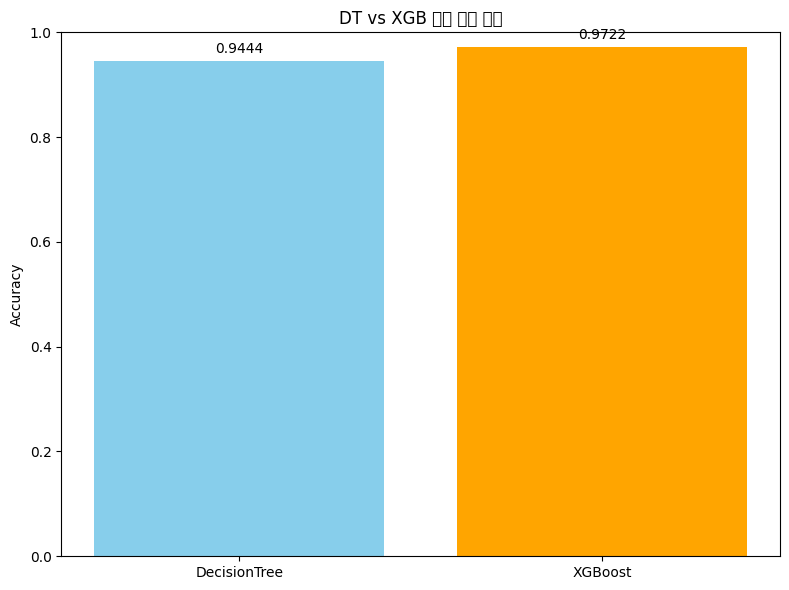

In [6]:
from sklearn.metrics import classification_report

# DT와 XGB 성능 비교 출력
print("=" * 25 + " DT 성능 확인 " + "=" * 25)
print(f"DT accuracy : {dt_accuracy}")
print(classification_report(y_test, dt_pred))

print("=" * 25 + " XGB 성능 확인 " + "=" * 25)
print(f"XGB accuracy : {xgb_accuracy}")
print(classification_report(y_test, xgb_pred))

models = ['DecisionTree', 'XGBoost']
accuracies = [dt_accuracy, xgb_accuracy]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=['skyblue', 'orange'])
plt.title('DT vs XGB 모델 성능 비교')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">